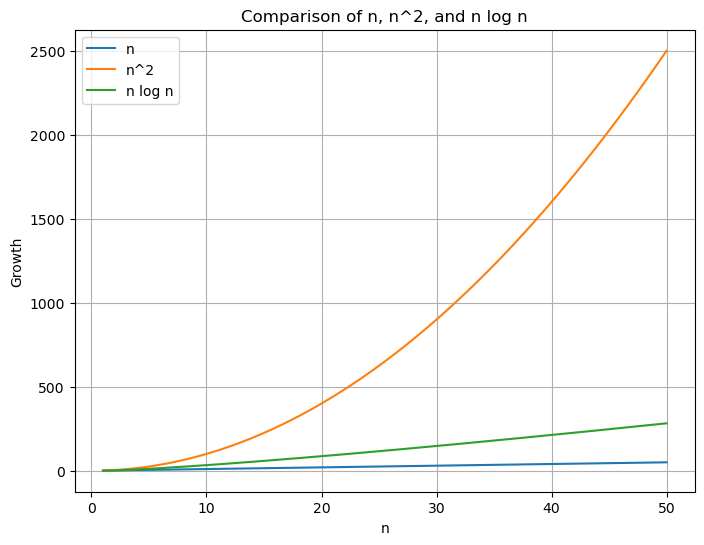

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Values of n
n = np.linspace(1, 50, 500)

# Functions
y1 = n
y2 = n**2
y3 = n * np.log2(n)   # You could also use np.log(n)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(n, y1, label='n')
plt.plot(n, y2, label='n^2')
plt.plot(n, y3, label='n log n')

plt.xlabel('n')
plt.ylabel('Growth')
plt.title('Comparison of n, n^2, and n log n')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
def hoare_partition(arr, low, high):
    pivot = arr[low]
    i = low - 1
    j = high + 1

    while True:
        i += 1
        while arr[i] < pivot:
            i += 1

        j -= 1
        while arr[j] > pivot:
            j -= 1

        if i >= j:
            return j

        arr[i], arr[j] = arr[j], arr[i]
        

In [9]:
a = [3, 7, 1, 4, 5]
j = hoare_partition(a, 0, len(a)-1)
print(f"j={j}  a: {a}")

j=0  a: [1, 7, 3, 4, 5]


In [17]:
def lomuto_partition(arr, low, high):
    pivot = arr[high]
    i = low  # boundary for <= pivot

    for j in range(low, high):
        if arr[j] <= pivot:
            arr[i], arr[j] = arr[j], arr[i]
            i += 1

    # place pivot in its final position
    arr[i], arr[high] = arr[high], arr[i]
    return i

In [18]:
a = [3, 7, 1, 4, 5]
i = lomuto_partition(a, 0, len(a)-1)
print(f"i={i}  a: {a}")

i=3  a: [3, 1, 4, 5, 7]


In [37]:
from IPython.display import display, Math

def pretty_partition(arr, low=None, high=None, pivot=None):
    """
    Pretty-print a 1D array in Jupyter as a LaTeX matrix with evenly spaced cells.

    Marking:
      - low index: underlined
      - high index: underlined
      - pivot index: boxed

    If an index has multiple roles, the decorations are combined.

    Example:
        a = [3, 7, 1, 4, 5]
        pretty_partition(a, low=0, high=4, pivot=2)
    """
    value_cells = []
    index_cells = []

    for i, x in enumerate(arr):
        value = str(x)
        idx = str(i)

        if i == low:
            value = rf"\underline{{{value}}}"

        if i == high:
            value = rf"\underline{{{value}}}"

        if i == pivot:
            value = rf"\boxed{{{value}}}"

        value_cells.append(value)

    values_row = " & ".join(value_cells)

    latex = rf"""
    \begin{{array}}{{{'c' * len(arr)}}}
    {values_row} 
    \end{{array}}
    """

    display(Math(latex))

In [38]:
def quicksort(arr, low=0, high=None):
    if high is None:
        high = len(arr) - 1

    if low < high:
        p = lomuto_partition(arr, low, high)
        pretty_partition(arr, low, high, p)
        quicksort(arr, low, p - 1)
        quicksort(arr, p + 1, high)

In [39]:
arr = [5, 12, 1, 16, 3, 9, 7, 14, 2, 11, 6, 15, 4, 10, 8, 13]
quicksort(arr)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [40]:
arr = [6, 2, 8, 1, 5, 3, 7, 4]
quicksort(arr)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>